### **Demo to run the code**
- Run the following and adjust hyperparams as needed for desired output.
- Code will automatically determine which device is best for your system.
- Image quality is more like AI image generation from 2022-2023, so do not expect the best photos.

Big thanks to [Umar Jamil](https://github.com/hkproj/pytorch-stable-diffusion/blob/main/sd/demo.ipynb) for walking me through diffusion and U-Nets.


C:\Users\Noah's PC\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


W0331 19:40:38.573000 31764 torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
100%|██████████| 50/50 [00:09<00:00,  5.30it/s]


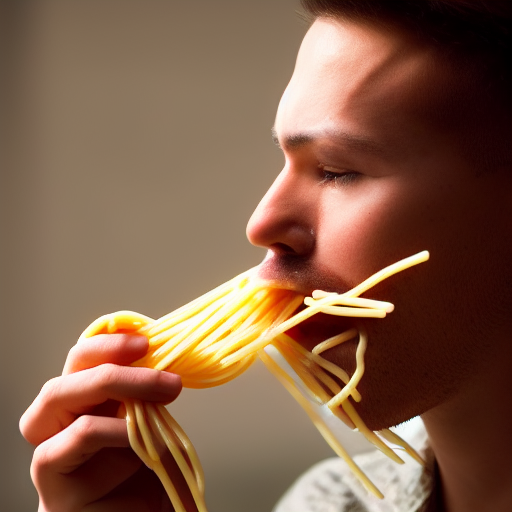

In [1]:

import model_loader
import pipeline
from PIL import Image
from pathlib import Path
from transformers import CLIPTokenizer
import torch

DEVICE = "cpu"

ALLOW_CUDA = True
ALLOW_MPS = False

if torch.cuda.is_available() and ALLOW_CUDA:
    DEVICE = "cuda"
elif (torch.backends.mps.is_built() or torch.backends.mps.is_available()) and ALLOW_MPS:
    DEVICE = "mps"
print(f"Using device: {DEVICE}")

tokenizer = CLIPTokenizer("../data/vocab.json", merges="../data/merges.txt")
model_file = "../data/v1-5-pruned-emaonly.ckpt"
models = model_loader.preload_models_from_standard_weights(model_file, DEVICE)

## --- TEXT TO IMAGE ---

prompt = "A person eatting spaghetti, highly detailed, ultra sharp, cinematic, 100mm lens, 8k resolution."
uncond_prompt = ""  # Also known as negative prompt
do_cfg = True
cfg_scale = 10 # min: 1, max: 14

## --- IMAGE TO IMAGE ---

input_image = None
# Comment to disable image to image
image_path = "../images/banana.jpg"
# input_image = Image.open(image_path)
# Higher values means more noise will be added to the input image, so the result will further from the input image.
# Lower values means less noise is added to the input image, so output will be closer to the input image.
strength = 0.3

## --- SAMPLER ---

sampler = "ddpm"
num_inference_steps = 50
seed = 42

output_image = pipeline.generator(
    prompt=prompt,
    unconditional_prompt=uncond_prompt,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scalar=cfg_scale,
    sampler_name=sampler,
    n_inference_steps=num_inference_steps,
    seed=seed,
    models=models,
    device=DEVICE,
    idle_device="cpu",
    tokenizer=tokenizer,
)

# Combine the input image and the output image into a single image.
Image.fromarray(output_image)